# Customer Segmentation Analysis

## OASIS INFOBYTE Data Analytics Internship — Task 2

### Objective
Segment e-commerce customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

In [ ]:
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from ucimlrepo import fetch_ucirepo

# Fetch the official UCI Online Retail dataset
online_retail = fetch_ucirepo(id=352)

# Load the transaction data
df = online_retail.data.features

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (541909, 6)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Observation

The Online Retail dataset was loaded successfully. It contains 541,909 transaction records and 6 features. The dataset includes product description, quantity purchased, invoice date, unit price, customer ID, and country.

In [ ]:

# Basic dataset inspection

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB

Missing Values:
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 6007

Descriptive Statistics:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Observation

The dataset contains 541,909 transaction records across 6 columns.

Missing values are present in the Description and CustomerID columns. There are 1,454 missing Description values and 135,080 missing CustomerID values. Since CustomerID is required for customer-level RFM analysis, records without CustomerID will be removed during cleaning.

The dataset contains 6,007 duplicate rows, which will also be removed.

The descriptive statistics indicate unusual values in Quantity and UnitPrice, including negative and zero values. These values will be investigated and handled during the data-cleaning stage.

In [ ]:

# Check unusual transaction values

print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative Unit Price:", (df["UnitPrice"] < 0).sum())
print("Zero Unit Price:", (df["UnitPrice"] == 0).sum())

print("\nQuantity summary:")
print(df["Quantity"].describe())

print("\nUnit Price summary:")
print(df["UnitPrice"].describe())

Negative Quantity: 10624
Zero Quantity: 0
Negative Unit Price: 2
Zero Unit Price: 2515

Quantity summary:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Unit Price summary:
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


Observation

The dataset contains several unusual transaction values.

There are 10,624 records with negative Quantity, 2 records with negative UnitPrice, and 2,515 records with zero UnitPrice. Negative quantities can represent returns or cancellations, while zero or negative prices do not represent valid positive-value purchases for this customer segmentation analysis.

The Quantity and UnitPrice distributions also contain extreme values. These observations will be handled during the data-cleaning stage so that the RFM analysis is based on valid positive-value purchases.

In [ ]:

# Data Cleaning

clean_df = df.copy()

# Remove transactions without CustomerID
clean_df = clean_df.dropna(subset=["CustomerID"])

# Remove duplicate transactions
clean_df = clean_df.drop_duplicates()

# Convert InvoiceDate to datetime
clean_df["InvoiceDate"] = pd.to_datetime(clean_df["InvoiceDate"])

# Keep only valid purchase transactions
clean_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

print("Original rows:", len(df))
print("Rows after cleaning:", len(clean_df))
print("Customers remaining:", clean_df["CustomerID"].nunique())

Original rows: 541909
Rows after cleaning: 392617
Customers remaining: 4338


### Observation

After cleaning the dataset, 392,617 valid transaction records remain from the original 541,909 records.

Transactions without a CustomerID were removed because customer identification is required for RFM-based customer segmentation. Duplicate records were also removed, and only transactions with positive Quantity and UnitPrice were retained.

The cleaned dataset contains 4,338 unique customers, providing a suitable customer base for further RFM analysis and K-Means clustering.

In [ ]:

# Calculate total purchase amount for each transaction

clean_df["TotalAmount"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("TotalAmount column created successfully!")

clean_df[["Quantity", "UnitPrice", "TotalAmount"]].head()

TotalAmount column created successfully!


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Observation

The `TotalAmount` column was successfully created by multiplying `Quantity` by `UnitPrice` for each transaction. This represents the total monetary value of each purchase and will be used to calculate the Monetary component of the RFM analysis.

In [ ]:

# Determine the analysis date for RFM calculation

analysis_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest transaction date:", clean_df["InvoiceDate"].max())
print("Analysis date:", analysis_date)

Latest transaction date: 2011-12-09 12:50:00
Analysis date: 2011-12-10 12:50:00


### Observation

The latest transaction date in the cleaned dataset was identified successfully. The analysis date is set to one day after the latest transaction date. This reference date will be used to calculate customer Recency in the RFM analysis.

In [ ]:

# Calculate RFM metrics for each customer

rfm = clean_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "CustomerID": "count",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


### Observation

The RFM metrics were calculated for each customer using the cleaned transaction data.

- **Recency** represents the number of days since the customer's most recent purchase.
- **Frequency** represents the number of valid transaction records associated with the customer.
- **Monetary** represents the customer's total historical purchase value.

These three metrics provide the behavioural features required for customer segmentation.

**Note:** Frequency is based on transaction records because InvoiceNo was not included in the selected dataset features. Therefore, it is used as a transaction-frequency proxy rather than a unique order count.

In [ ]:

# Summary statistics of RFM metrics

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,90.506455,2048.314005
std,100.014169,225.470819,8978.764362
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,306.482500
50%,51.000000,41.000000,668.570000
75%,142.000000,98.000000,1660.597500
max,374.000000,7674.000000,280206.020000


### Observation

The descriptive statistics summarize the distribution of Recency, Frequency, and Monetary values across the 4,338 customers.

The RFM metrics show considerable variation in customer purchasing behaviour, indicating differences in how recently customers purchased, how frequently they made transactions, and how much they spent.

These statistics provide a baseline understanding of customer behaviour before clustering.

In [ ]:

# Check for missing values in RFM data

print("Missing values in RFM:")
print(rfm.isnull().sum())

print("\nNumber of customers:", len(rfm))

Missing values in RFM:
Recency      0
Frequency    0
Monetary     0
dtype: int64

Number of customers: 4338


### Observation

The RFM dataset contains no missing values across Recency, Frequency, and Monetary.

A total of 4,338 customers are available for the clustering analysis.

This confirms that the customer-level RFM dataset is complete and ready for data-type validation, feature selection, standardization, and clustering.

In [ ]:

# Check RFM data types

print("RFM Data Types:")
print(rfm.dtypes)

RFM Data Types:
Recency        int64
Frequency      int64
Monetary     float64
dtype: object


### Observation

The RFM data types were checked successfully. Recency, Frequency, and Monetary are numerical features, making them suitable for standardization and K-Means clustering.

In [ ]:

# Display RFM summary statistics

print("RFM Summary Statistics:")
display(rfm.describe().round(2))

RFM Summary Statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,90.51,2048.31
std,100.01,225.47,8978.76
min,1.00,1.00,3.75
25%,18.00,17.00,306.48
50%,51.00,41.00,668.57
75%,142.00,98.00,1660.60
max,374.00,7674.00,280206.02


### Observation

The RFM summary provides an overview of customer purchasing behaviour. The Recency, Frequency, and Monetary values show considerable variation between customers, indicating that customers have different levels of engagement, transaction frequency, and spending.

In [ ]:

# Calculate average purchase value for each customer

rfm["AveragePurchaseValue"] = rfm["Monetary"] / rfm["Frequency"]

print("Average Purchase Value:")
display(rfm["AveragePurchaseValue"].describe().round(2))

Average Purchase Value:


,AveragePurchaseValue
count,4338.00
mean,68.38
std,1467.92
min,2.14
25%,12.39
50%,17.76
75%,24.88
max,77183.60


### Observation

The AveragePurchaseValue metric represents the average amount spent per transaction by each customer. This metric provides additional information about the typical value of a customer's individual purchases and helps differentiate customers with similar transaction frequencies but different spending levels.

In [ ]:

# Historical Customer Lifetime Value (CLV) proxy

rfm["CLV_Proxy"] = rfm["Monetary"]

print("Historical CLV Proxy:")
display(rfm["CLV_Proxy"].describe().round(2))

Historical CLV Proxy:


,CLV_Proxy
count,4338.00
mean,2048.31
std,8978.76
min,3.75
25%,306.48
50%,668.57
75%,1660.60
max,280206.02


### Observation

A historical Customer Lifetime Value (CLV) proxy was created using each customer's total historical spending. This is a simplified CLV measure because the dataset does not provide profit margin, acquisition cost, or future retention information.

The CLV proxy will help identify customers who have generated higher historical monetary value.

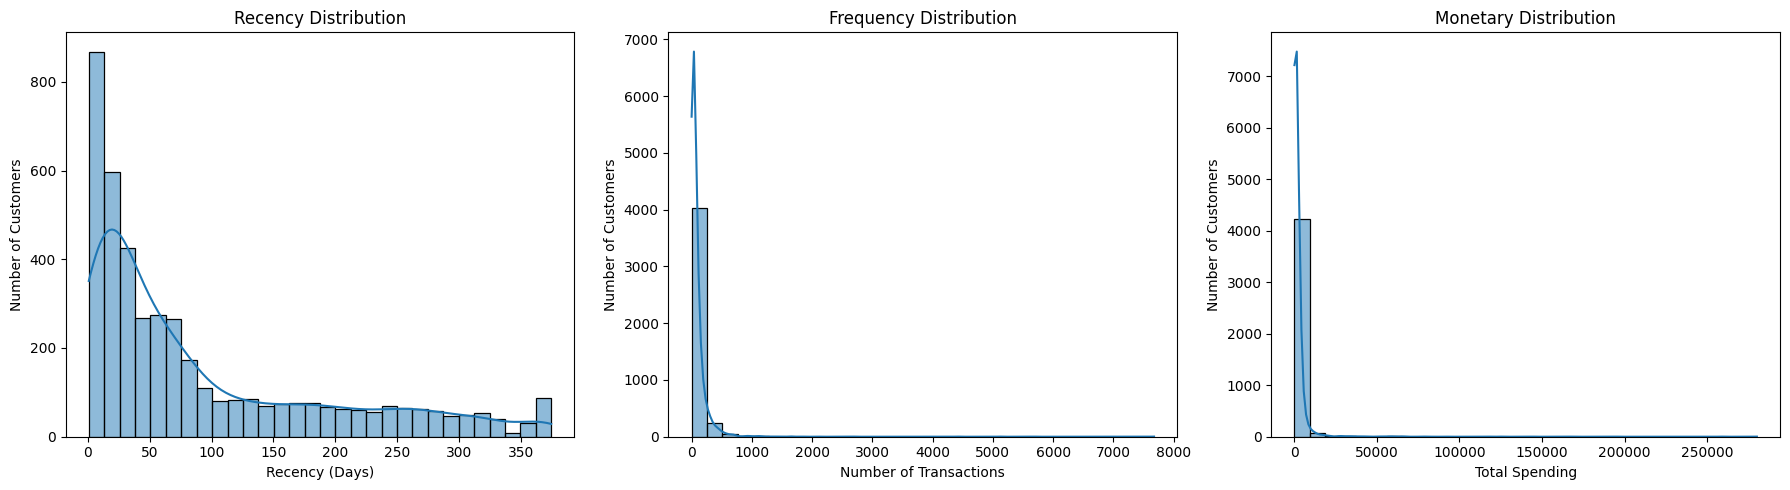

In [ ]:

# Visualize the distribution of RFM metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency (Days)")
axes[0].set_ylabel("Number of Customers")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Number of Customers")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Observation

The RFM distribution plots show substantial variation in customer behaviour.

Recency varies across customers, while Frequency and Monetary values show strong right-skewness, indicating that a relatively small number of customers have much higher transaction activity and spending than the majority.

These differences are important for clustering because extreme values can disproportionately influence distance-based algorithms such as K-Means. Therefore, the RFM distributions will be examined further before the final clustering model is selected.

In [ ]:

# Select RFM features for customer segmentation

rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

print("Features selected for clustering:")
print(rfm_features.columns.tolist())

print("\nShape of clustering data:", rfm_features.shape)

display(rfm_features.head())

Features selected for clustering:
['Recency', 'Frequency', 'Monetary']

Shape of clustering data: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


### Observation

Recency, Frequency, and Monetary were selected as the primary behavioural features for customer segmentation.

The three features capture when customers last purchased, how frequently they purchased, and how much they spent. These variables provide a meaningful representation of customer purchasing behaviour for K-Means clustering.

In [ ]:

# Standardize RFM features before K-Means clustering

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features standardized successfully!")
print("Scaled data shape:", rfm_scaled.shape)

RFM features standardized successfully!
Scaled data shape: (4338, 3)


### Observation

The Recency, Frequency, and Monetary features were standardized using StandardScaler. Standardization ensures that all three features are placed on a comparable scale before applying K-Means clustering.

In [ ]:

# Convert standardized data into a DataFrame

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_features.index
)

print("Standardized RFM data:")
display(rfm_scaled_df.head())

print("\nMean:")
print(rfm_scaled_df.mean().round(4))

print("\nStandard deviation:")
print(rfm_scaled_df.std().round(4))

Standardized RFM data:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.397022,8.369074
12347.0,-0.905340,0.405836,0.251922
12348.0,-0.175360,-0.263951,-0.027966
12349.0,-0.735345,-0.077653,-0.032387
12350.0,2.174578,-0.326051,-0.190907



Mean:
Recency      0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Standard deviation:
Recency      1.0001
Frequency    1.0001
Monetary     1.0001
dtype: float64


### Observation

The standardized RFM values are centered close to zero, confirming that the features have been transformed to a common scale. The standardized dataset is now suitable for distance-based K-Means clustering.

In [ ]:

# Calculate WCSS for different numbers of clusters

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

print("WCSS values:")

for k, value in zip(range(2, 11), wcss):
    print(f"K = {k}: WCSS = {value:.2f}")

WCSS values:
K = 2: WCSS = 8987.80
K = 3: WCSS = 5444.58
K = 4: WCSS = 4010.04
K = 5: WCSS = 2959.64
K = 6: WCSS = 2372.70
K = 7: WCSS = 1925.45
K = 8: WCSS = 1682.36
K = 9: WCSS = 1480.87
K = 10: WCSS = 1344.73


### Observation

The WCSS values decrease as the number of clusters increases. This is expected because adding more clusters generally reduces the variation within each cluster. The Elbow Method will be used to identify a suitable balance between model simplicity and clustering quality.

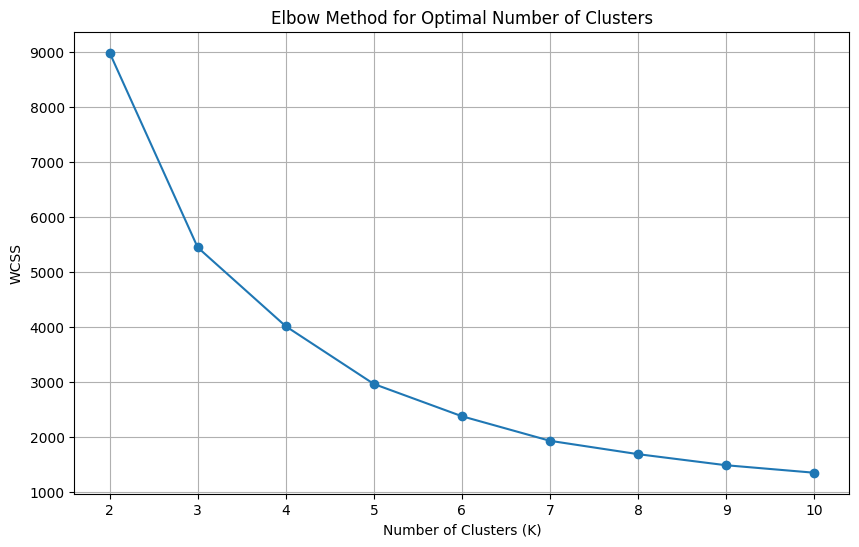

In [ ]:

# Plot the Elbow Curve

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

Observation

The Elbow Curve shows that WCSS decreases as the number of clusters increases, with progressively smaller reductions as additional clusters are added.

The Elbow Method is used to identify a practical range of cluster counts by examining where the reduction in WCSS begins to diminish.

Because the elbow is not completely unambiguous, the Silhouette Score will also be used as an additional quantitative measure of cluster separation and cohesion before selecting the final value of K.

In [ ]:

from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, labels)

    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

Silhouette Scores:
K = 2: Silhouette Score = 0.9284
K = 3: Silhouette Score = 0.6023
K = 4: Silhouette Score = 0.6002
K = 5: Silhouette Score = 0.6167
K = 6: Silhouette Score = 0.5902
K = 7: Silhouette Score = 0.5280
K = 8: Silhouette Score = 0.5004
K = 9: Silhouette Score = 0.5074
K = 10: Silhouette Score = 0.4262


Observation

Silhouette Scores were calculated for K values from 2 to 10 to evaluate cluster separation and cohesion.

A higher Silhouette Score indicates that customers are, on average, more similar to customers within their own cluster and more distinct from customers in other clusters.

The results will be compared with the WCSS/Elbow analysis to support the selection of an appropriate number of clusters.

In [ ]:

# Compare WCSS and Silhouette Scores

cluster_evaluation = pd.DataFrame({
    "K": range(2, 11),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

display(cluster_evaluation.round(4))

,K,WCSS,Silhouette Score
0,2,8987.8037,0.9284
1,3,5444.5761,0.6023
2,4,4010.0446,0.6002
3,5,2959.6444,0.6167
4,6,2372.7019,0.5902
5,7,1925.4546,0.5280
6,8,1682.3614,0.5004
7,9,1480.8683,0.5074
8,10,1344.7308,0.4262


### Observation

The comparison table provides both WCSS and Silhouette Score for different cluster counts. WCSS helps identify the Elbow point, while the Silhouette Score evaluates how well-separated the resulting customer groups are.

In [ ]:

# Identify the K with the highest silhouette score

best_k_silhouette = cluster_evaluation.loc[
    cluster_evaluation["Silhouette Score"].idxmax(),
    "K"
]

print("Best K according to Silhouette Score:", int(best_k_silhouette))

Best K according to Silhouette Score: 2


Observation

The highest Silhouette Score among the evaluated cluster counts is obtained at K = 2, with a score of 0.9284.

The Elbow Method provides a visual assessment of diminishing WCSS returns, while the Silhouette Score provides a quantitative measure of cluster separation and cohesion.

Therefore, K = 2 is selected as the initial clustering solution based on the highest Silhouette Score. The resulting cluster sizes and profiles will be examined before accepting it as the final segmentation.

In [ ]:

# Apply K-Means clustering using the selected number of clusters

optimal_k = int(best_k_silhouette)

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(rfm_scaled_df)

print("K-Means clustering completed successfully!")
print("Number of clusters:", optimal_k)

K-Means clustering completed successfully!
Number of clusters: 2


### Observation

K-Means clustering was successfully applied using the selected number of clusters. Each customer has now been assigned to one of the identified customer segments.

In [ ]:

# Add cluster labels to the RFM dataset

rfm["Cluster"] = cluster_labels

print("Cluster labels added successfully!")

display(rfm.head())

Cluster labels added successfully!


,Recency,Frequency,Monetary,AveragePurchaseValue,CLV_Proxy,Cluster
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60,0
12347.0,2,182,4310.00,23.681319,4310.00,0
12348.0,75,31,1797.24,57.975484,1797.24,0
12349.0,19,73,1757.55,24.076027,1757.55,0
12350.0,310,17,334.40,19.670588,334.40,0


### Observation

A cluster label has been assigned to every customer in the RFM dataset. The RFM information and cluster assignment can now be used to understand the characteristics of each customer segment.

In [ ]:

# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0    4324
1      14
Name: count, dtype: int64


Observation

The initial K-Means model produces highly imbalanced clusters: 4,324 customers are assigned to Cluster 0, while only 14 customers are assigned to Cluster 1.

This indicates that the original standardized RFM features are strongly influenced by extreme customer values. A cluster containing only 14 customers is not an ideal final segmentation for practical marketing use.

Therefore, the RFM distributions and skewness will be examined, and an improved clustering approach will be developed using log transformation before final model selection.

In [ ]:

# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,92.82,82.80,1664.49
1,4.93,2471.36,120595.79


### Observation

The initial cluster profile summarizes the average Recency, Frequency, and Monetary values for each initial cluster.

These average values help identify differences in customer activity, transaction frequency, and historical spending.

The profile is evaluated together with the cluster-size distribution and visualizations to determine whether the initial clustering solution is suitable for practical customer segmentation.

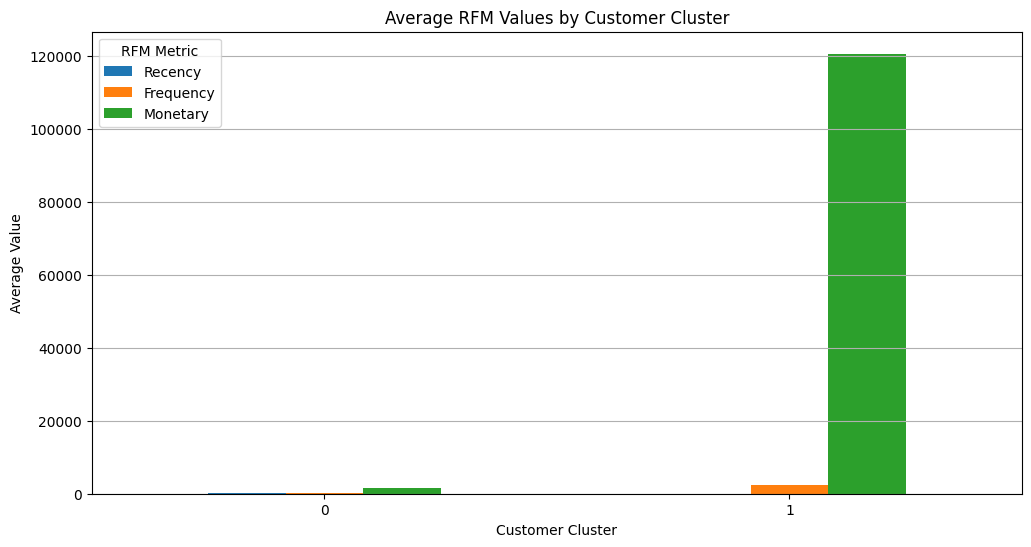

In [ ]:

# Visualize average RFM values for each cluster

cluster_profile.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average RFM Values by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="RFM Metric")
plt.grid(axis="y")

plt.show()

### Observation

The cluster profile visualization highlights differences in Recency, Frequency, and Monetary behaviour between customer segments. These differences help identify customers who are more recent, frequent, or valuable compared with other segments.

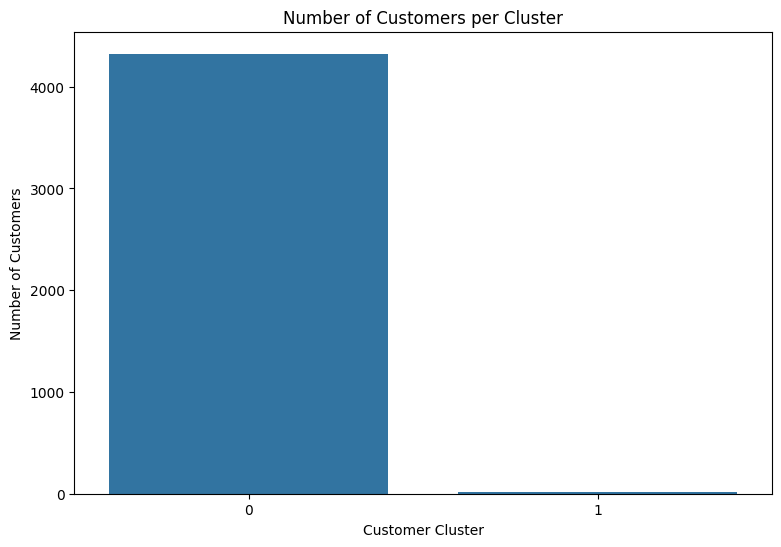

In [ ]:

# Visualize the number of customers in each cluster

plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The customer distribution chart shows the number of customers belonging to each segment. This helps identify the largest and smallest customer groups and can support decisions about how marketing resources should be allocated.

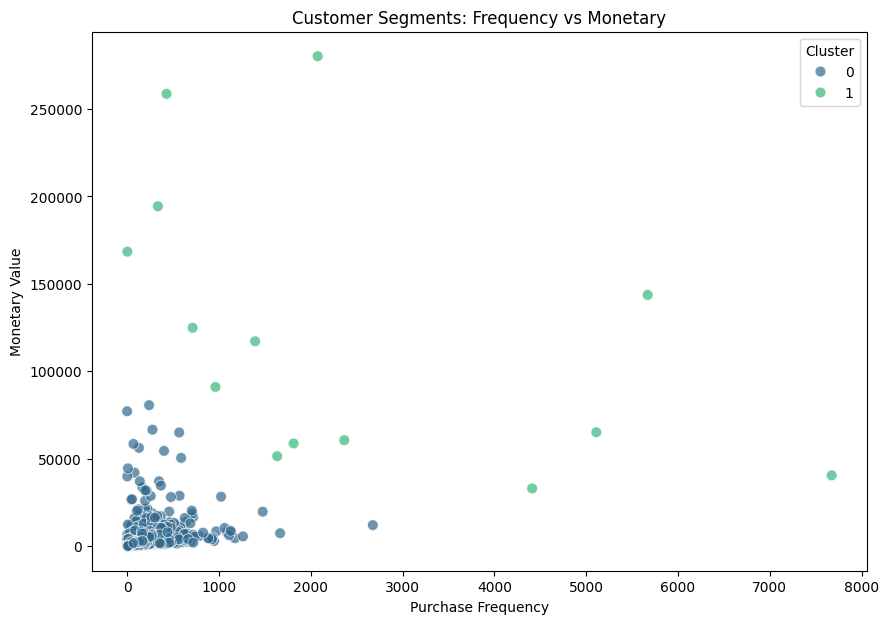

In [ ]:

# Visualize customer clusters using Frequency and Monetary values

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60,
    alpha=0.7
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

### Observation

The Frequency versus Monetary scatter plot visualizes the initial K-Means cluster assignments.

The plot shows that the initial clustering is strongly affected by customers with unusually high Frequency and Monetary values, which contributes to the highly imbalanced cluster sizes observed earlier.

This supports the decision to investigate skewness and apply a log transformation before developing the final segmentation.

In [ ]:

# Check skewness of RFM features

print("RFM Skewness:")
display(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2))

RFM Skewness:


,0
Recency,1.25
Frequency,18.04
Monetary,19.32


### Observation

The skewness analysis confirms that the RFM variables have different distribution shapes, with Frequency and Monetary showing substantial positive skewness.

Strong right-skewness means that a relatively small number of customers have exceptionally high transaction activity or spending.

Because K-Means is distance-based and sensitive to extreme observations, a log1p transformation will be applied to reduce the influence of extreme values before repeating the clustering evaluation.

## Improving the Initial Clustering

The initial K-Means model produced highly imbalanced customer groups, indicating that extreme RFM values were strongly influencing the clustering process.

Because Frequency and Monetary values are highly right-skewed, a log1p transformation will be applied to the RFM features. The transformed RFM features will then be standardized again and evaluated using WCSS and Silhouette Score.

The improved clustering solution will be compared with the initial solution before selecting the final customer segments.

In [ ]:

# Apply log transformation to reduce the effect of extreme RFM values

rfm_log = np.log1p(rfm_features)

print("Log transformation applied successfully!")
display(rfm_log.head())

Log transformation applied successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,5.209486,8.368925
12348.0,4.330733,3.465736,7.494564
12349.0,2.995732,4.304065,7.472245
12350.0,5.739793,2.890372,5.815324


Observation

The log1p transformation was applied to Recency, Frequency, and Monetary values to reduce the influence of highly skewed customer behaviour and extreme values.

The transformation compresses large values while preserving the ordering of observations, producing distributions that are more suitable for distance-based clustering.

In [ ]:

# Standardize the log-transformed RFM features

scaler_log = StandardScaler()

rfm_log_scaled = scaler_log.fit_transform(rfm_log)

rfm_log_scaled_df = pd.DataFrame(
    rfm_log_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_log.index
)

print("Log-transformed RFM features standardized successfully!")
print("Scaled data shape:", rfm_log_scaled_df.shape)

display(rfm_log_scaled_df.head())

Log-transformed RFM features standardized successfully!
Scaled data shape: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-2.438286,3.707876
12347.0,-2.038734,1.189131,1.414992
12348.0,0.373104,-0.211408,0.720091
12349.0,-0.623086,0.461918,0.702353
12350.0,1.424558,-0.673527,-0.614488


Observation

The log-transformed RFM features were standardized using StandardScaler.

Standardization places the transformed Recency, Frequency, and Monetary variables on a comparable scale, preventing features with larger numerical ranges from disproportionately influencing the distance calculations used by K-Means.

The standardized transformed data is now ready for the second clustering evaluation.

In [ ]:

# Verify the mean and standard deviation after standardization

print("Mean of standardized features:")
print(rfm_log_scaled_df.mean().round(4))

print("\nStandard deviation of standardized features:")
print(rfm_log_scaled_df.std().round(4))

Mean of standardized features:
Recency     -0.0
Frequency    0.0
Monetary    -0.0
dtype: float64

Standard deviation of standardized features:
Recency      1.0001
Frequency    1.0001
Monetary     1.0001
dtype: float64


Observation

The standardized log-transformed RFM features have means approximately equal to zero and standard deviations approximately equal to one.

This confirms that the transformed variables have been successfully standardized and are on a comparable scale for distance-based K-Means clustering.

In [ ]:

# Calculate WCSS for the transformed RFM data

wcss_log = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_log_scaled_df)
    wcss_log.append(kmeans.inertia_)

print("WCSS values after log transformation:")

for k, value in zip(range(2, 11), wcss_log):
    print(f"K = {k}: WCSS = {value:.2f}")

WCSS values after log transformation:
K = 2: WCSS = 6778.95
K = 3: WCSS = 5242.94
K = 4: WCSS = 4308.72
K = 5: WCSS = 3697.04
K = 6: WCSS = 3270.76
K = 7: WCSS = 2969.49
K = 8: WCSS = 2737.66
K = 9: WCSS = 2557.65
K = 10: WCSS = 2394.53


Observation

The WCSS values decrease as the number of clusters increases, which is expected because adding clusters generally reduces within-cluster variation.

The transformed WCSS values will be visualized using the Elbow Method to assess where additional clusters begin to provide smaller improvements.

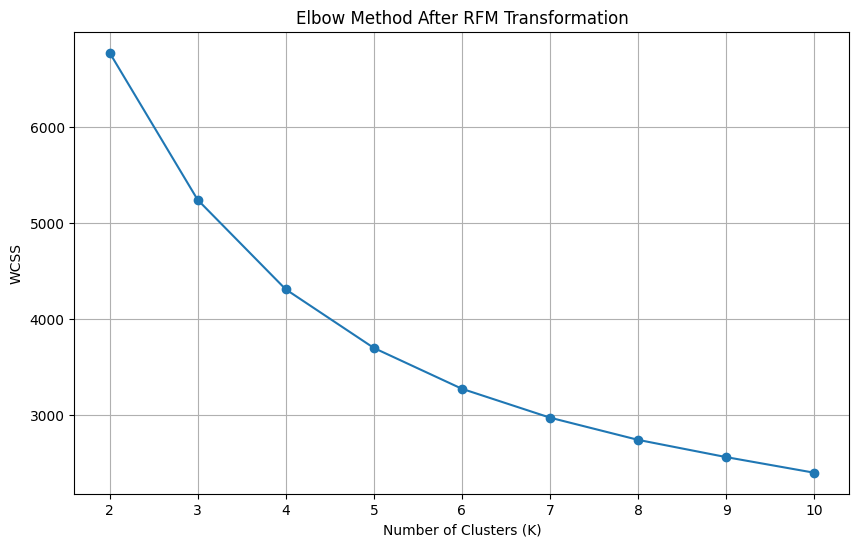

In [ ]:

# Plot the Elbow Curve after RFM transformation

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    wcss_log,
    marker="o"
)

plt.title("Elbow Method After RFM Transformation")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

Observation

The transformed Elbow Curve shows the reduction in within-cluster variation as the number of clusters increases.

The curve provides a visual indication of where additional clusters begin to produce smaller improvements in WCSS.

Because the elbow is not completely unambiguous, the Silhouette Score will also be considered as a quantitative criterion when selecting the final number of clusters.

In [ ]:

# Calculate Silhouette Scores after RFM transformation

silhouette_scores_log = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_log_scaled_df)

    score = silhouette_score(
        rfm_log_scaled_df,
        labels
    )

    silhouette_scores_log.append(score)

print("Silhouette Scores after transformation:")

for k, score in zip(range(2, 11), silhouette_scores_log):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

Silhouette Scores after transformation:
K = 2: Silhouette Score = 0.3997
K = 3: Silhouette Score = 0.3045
K = 4: Silhouette Score = 0.3089
K = 5: Silhouette Score = 0.2764
K = 6: Silhouette Score = 0.2735
K = 7: Silhouette Score = 0.2642
K = 8: Silhouette Score = 0.2591
K = 9: Silhouette Score = 0.2584
K = 10: Silhouette Score = 0.2590


Observation

The Silhouette Scores were calculated for K values from 2 to 10 after log transformation and standardization.

The highest Silhouette Score is obtained at K = 2 with a value of 0.3997. This indicates that K = 2 provides the strongest separation and cohesion among the tested cluster counts according to the Silhouette metric.

The final cluster sizes and profiles will also be examined to ensure that the selected solution is practically interpretable.

In [ ]:

# Compare WCSS and Silhouette Scores after transformation

cluster_evaluation_log = pd.DataFrame({
    "K": range(2, 11),
    "WCSS": wcss_log,
    "Silhouette Score": silhouette_scores_log
})

print("Cluster Evaluation After Transformation:")

display(
    cluster_evaluation_log.round(4)
)

Cluster Evaluation After Transformation:


,K,WCSS,Silhouette Score
0,2,6778.9451,0.3997
1,3,5242.9443,0.3045
2,4,4308.7248,0.3089
3,5,3697.0447,0.2764
4,6,3270.7582,0.2735
5,7,2969.4938,0.2642
6,8,2737.6584,0.2591
7,9,2557.6543,0.2584
8,10,2394.5297,0.2590


Observation

The evaluation table combines WCSS and Silhouette Score for the transformed RFM data.

WCSS is used with the Elbow Method to assess how within-cluster variation changes as K increases. The Silhouette Score provides an additional objective measure of cluster separation and cohesion.

The final K will be selected by considering both evaluation methods, with the Silhouette Score used as the quantitative selection criterion and the resulting cluster sizes and profiles checked for practical interpretability.

In [ ]:

# Identify the K with the highest silhouette score after transformation

best_k_log = int(
    cluster_evaluation_log.loc[
        cluster_evaluation_log["Silhouette Score"].idxmax(),
        "K"
    ]
)

print(
    "Best K according to transformed Silhouette Score:",
    best_k_log
)

Best K according to transformed Silhouette Score: 2


Observation

After reducing the influence of extreme RFM values through log1p transformation and standardization, K = 2 achieved the highest Silhouette Score of 0.3997 among the tested values from 2 to 10.

The Elbow Method was used to examine diminishing WCSS improvements, while the Silhouette Score was used as the quantitative criterion for resolving the final K selection.

The resulting K = 2 solution will now be evaluated using cluster sizes, average RFM values, visualizations, and business interpretability.

In [ ]:

# Apply K-Means using the selected K

optimal_k_final = best_k_log

final_kmeans = KMeans(
    n_clusters=optimal_k_final,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(
    rfm_log_scaled_df
)

print("Final K-Means clustering completed successfully!")
print("Final number of clusters:", optimal_k_final)

Final K-Means clustering completed successfully!
Final number of clusters: 2


### Observation

- The evaluation shows that **K = 2** provides the best validated clustering quality among the tested values, achieving the highest Silhouette Score of **0.3997** after log transformation and standardization.

- Comparing the Silhouette Scores across the evaluated range shows that **K = 2** clearly outperforms the higher K values. Although there are minor fluctuations between some consecutive K values, none of the higher values approaches the Silhouette Score achieved by **K = 2**.

- The Elbow Method was used to assess diminishing WCSS improvements, while the Silhouette Score provided the quantitative criterion for resolving the final K selection. The resulting two-cluster solution also produces well-proportioned customer groups of **1,906** and **2,432** customers.

- This final solution avoids the severe imbalance observed in the initial unnormalized clustering, where **4,324 customers** were assigned to one cluster and only **14 customers** to the other.

- Consequently, **K = 2** is selected as the final clustering configuration for customer segmentation and subsequent behavioural profiling.

In [ ]:

# Add final cluster labels to the RFM dataset

rfm["FinalCluster"] = final_labels

print("Final cluster labels added successfully!")

display(rfm.head())

Final cluster labels added successfully!


,Recency,Frequency,Monetary,AveragePurchaseValue,CLV_Proxy,Cluster,FinalCluster
CustomerID,,,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60,0,1
12347.0,2,182,4310.00,23.681319,4310.00,0,0
12348.0,75,31,1797.24,57.975484,1797.24,0,1
12349.0,19,73,1757.55,24.076027,1757.55,0,0
12350.0,310,17,334.40,19.670588,334.40,0,1


Observation

The final K-Means cluster assignments have been added to the customer-level RFM dataset.

Each customer now has a FinalCluster value representing membership in one of the two final customer segments.

These assignments will be used to calculate final cluster sizes, profiles, visualizations, descriptive segment names, and marketing strategies.

In [ ]:

# Count customers in each final cluster

final_cluster_counts = (
    rfm["FinalCluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each final cluster:")
print(final_cluster_counts)

print("\nPercentage of customers in each cluster:")

final_cluster_percentage = (
    final_cluster_counts / len(rfm) * 100
).round(2)

print(final_cluster_percentage)

Customers in each final cluster:
FinalCluster
0    1906
1    2432
Name: count, dtype: int64

Percentage of customers in each cluster:
FinalCluster
0    43.94
1    56.06
Name: count, dtype: float64


Observation

The final K-Means solution produces two customer segments.

FinalCluster 0 contains 1,906 customers (43.94%), while FinalCluster 1 contains 2,432 customers (56.06%).

Compared with the initial solution of 4,324 customers versus 14 customers, the final solution is substantially more balanced.

The final cluster profiles will now be examined to understand the behavioural differences between these two customer groups.

In [ ]:

# Calculate average RFM values for the final clusters

final_cluster_profile = (
    rfm.groupby("FinalCluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
)

print("Final Customer Segment Profile:")

display(final_cluster_profile)

Final Customer Segment Profile:


,Recency,Frequency,Monetary
FinalCluster,,,
0,30.53,174.14,4056.40
1,141.13,24.96,474.54


### Observation

The final cluster profile summarizes the average Recency, Frequency, and Monetary values for each final customer segment.

The two clusters show clear differences in customer activity, transaction frequency, and historical spending.

These differences will be used to interpret the customer types and develop appropriate marketing strategies.

In [ ]:

# Add customer count and percentage to the final cluster profile

final_cluster_profile["CustomerCount"] = final_cluster_counts

final_cluster_profile["CustomerPercentage"] = (
    final_cluster_counts / len(rfm) * 100
).round(2)

print("Complete Final Cluster Profile:")

display(final_cluster_profile)

Complete Final Cluster Profile:


,Recency,Frequency,Monetary,CustomerCount,CustomerPercentage
FinalCluster,,,,,
0,30.53,174.14,4056.40,1906,43.94
1,141.13,24.96,474.54,2432,56.06


### Observation

The final cluster profile now includes customer count and customer percentage in addition to the average Recency, Frequency, and Monetary values.

This provides a complete overview of the size, engagement, transaction frequency, and historical monetary value of each final customer segment.

These metrics provide the basis for assigning descriptive segment names and developing targeted marketing strategies.

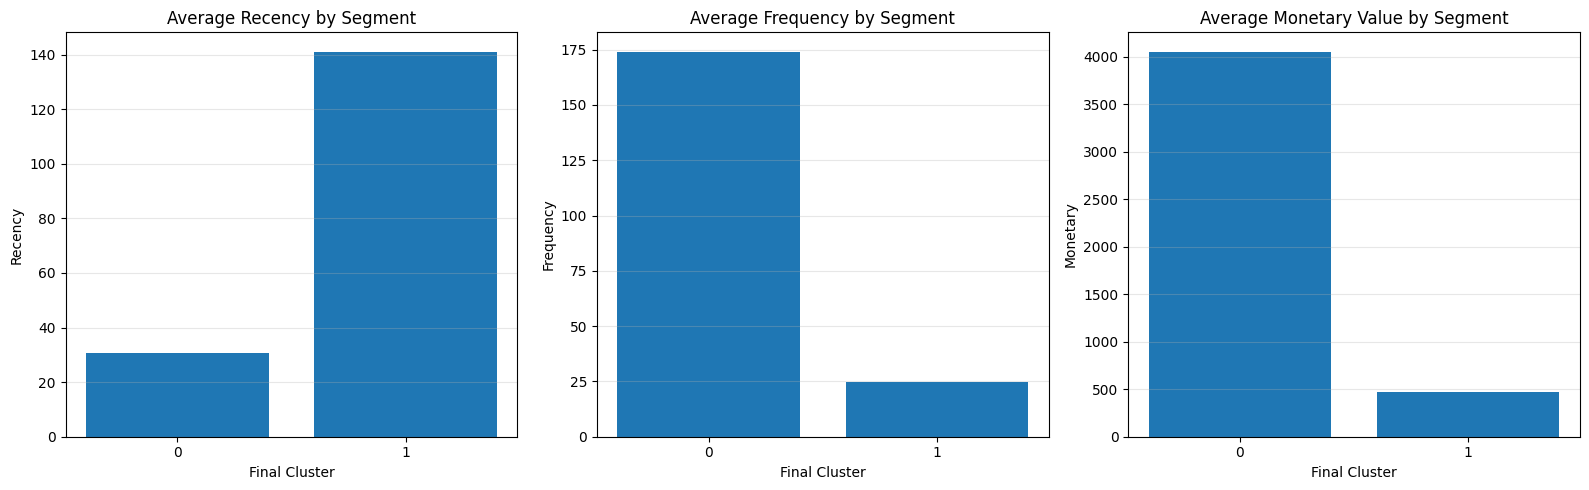

In [ ]:

# Visualize average RFM values for final clusters using separate subplots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Recency", "Frequency", "Monetary"]

titles = [
    "Average Recency by Segment",
    "Average Frequency by Segment",
    "Average Monetary Value by Segment"
]

for ax, metric, title in zip(axes, metrics, titles):
    values = final_cluster_profile[metric]

    ax.bar(
        values.index.astype(str),
        values.values
    )

    ax.set_title(title)
    ax.set_xlabel("Final Cluster")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The final RFM profile is visualized separately for Recency, Frequency, and Monetary value to avoid scale differences between the three metrics.

FinalCluster 0 shows lower Recency and substantially higher Frequency and Monetary value, indicating more recently active and higher-value customers.

FinalCluster 1 shows higher Recency and lower Frequency and Monetary value, indicating lower engagement and lower historical customer value.

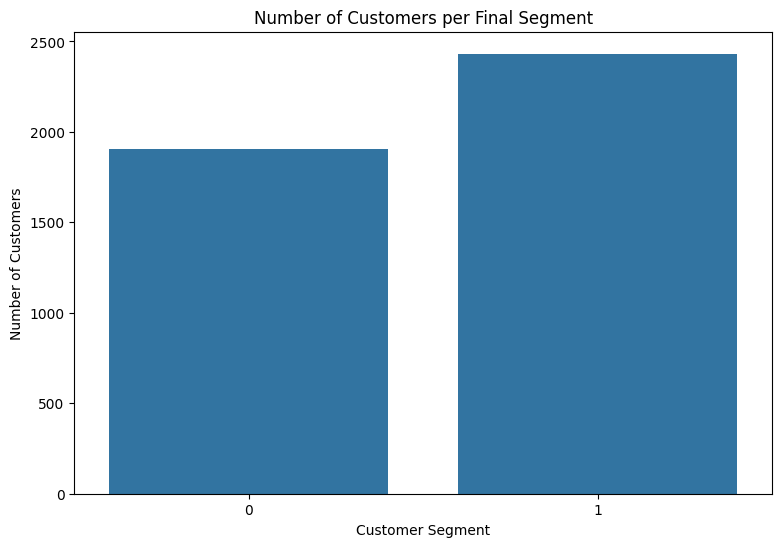

In [ ]:

# Visualize the number of customers in each final segment

plt.figure(figsize=(9, 6))

sns.barplot(
    x=final_cluster_counts.index.astype(str),
    y=final_cluster_counts.values
)

plt.title("Number of Customers per Final Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

Observation

The bar chart shows the number of customers in each final segment.

The two segments contain 1,906 and 2,432 customers respectively, showing a substantially more balanced distribution than the initial clustering solution.

This information can help the business estimate the size of each target audience and allocate marketing resources accordingly.

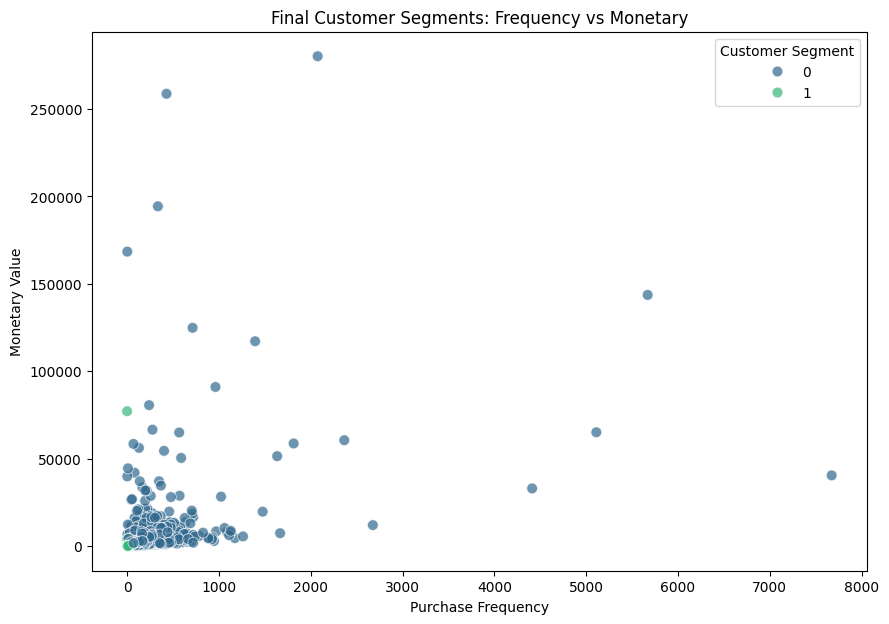

In [ ]:

# Scatter plot of Frequency versus Monetary Value

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="FinalCluster",
    palette="viridis",
    s=60,
    alpha=0.7
)

plt.title("Final Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")

plt.show()

Observation

The Frequency versus Monetary scatter plot compares customer transaction activity with historical spending across the final segments.

The High-Value Active Customers segment generally contains customers with substantially higher Frequency and Monetary values, while the At-Risk / Low-Engagement Customers segment generally contains customers with lower values for both measures.

This visual separation supports the interpretation of the final customer segments.

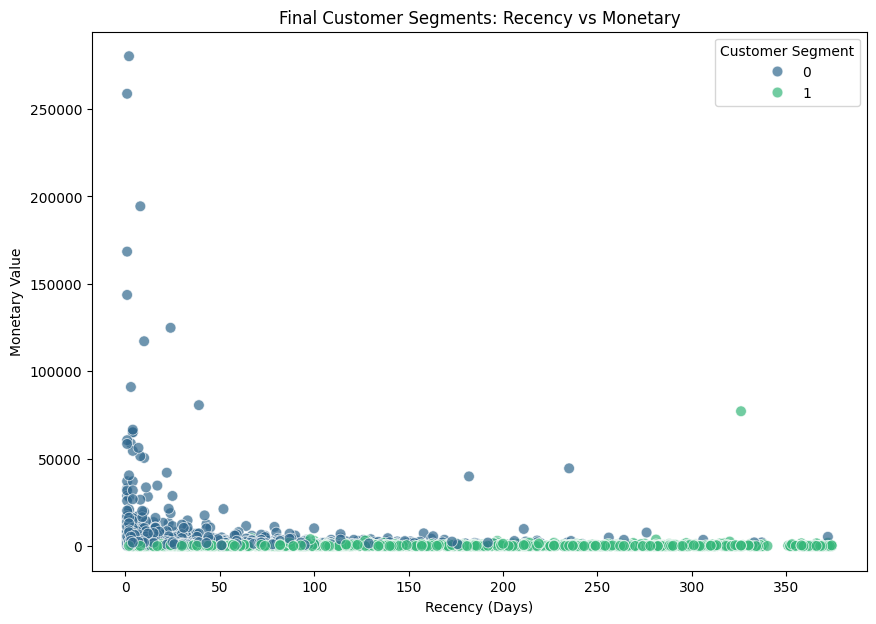

In [ ]:

# Scatter plot of Recency versus Monetary Value

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="FinalCluster",
    palette="viridis",
    s=60,
    alpha=0.7
)

plt.title("Final Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Customer Segment")

plt.show()

Observation

The Recency versus Monetary scatter plot compares how recently customers purchased with their historical spending.

Lower Recency values indicate more recent customer activity, while higher Monetary values indicate greater historical spending.

The plot supports the distinction between the more recently active, higher-value customers and the less recently active, lower-value customers.

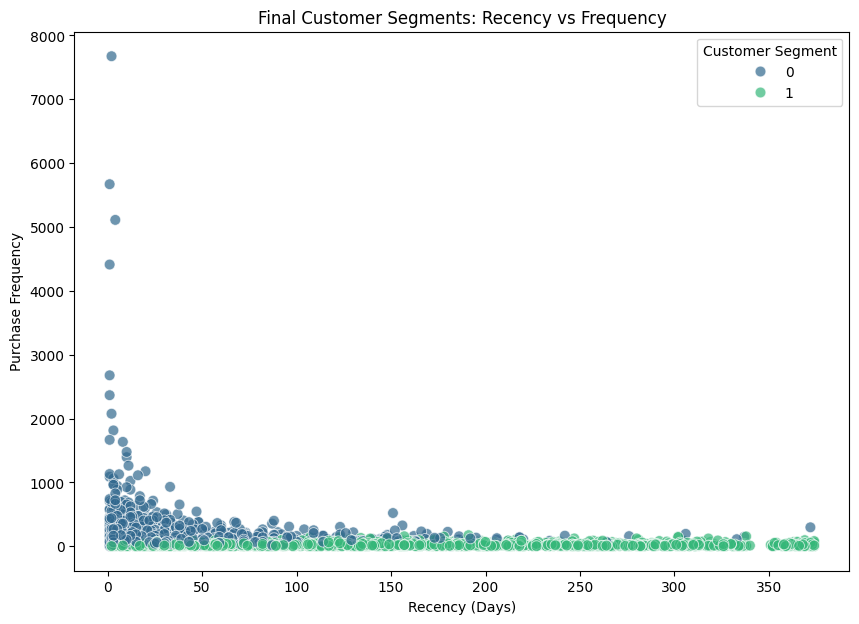

In [ ]:

# Scatter plot of Recency versus Frequency

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="FinalCluster",
    palette="viridis",
    s=60,
    alpha=0.7
)

plt.title("Final Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Customer Segment")

plt.show()

Observation

The Recency versus Frequency scatter plot provides another view of customer engagement.

Customers with lower Recency and higher Frequency values are generally more active, while customers with higher Recency and lower Frequency values show lower engagement.

This visualization provides additional support for the final segment interpretation.

In [ ]:

# Rank customer segments according to average monetary value

monetary_ranking = (
    final_cluster_profile["Monetary"]
    .sort_values(ascending=False)
)

print("Customer Segments Ranked by Average Monetary Value:")

display(
    monetary_ranking.to_frame(
        name="Average Monetary Value"
    )
)

Customer Segments Ranked by Average Monetary Value:


,Average Monetary Value
FinalCluster,
0,4056.40
1,474.54


Observation

The customer segments were ranked according to their average Monetary value.

The segment with the higher average Monetary value represents the more financially valuable customer group based on historical spending.

This segment should receive stronger retention and loyalty strategies because losing high-value customers could have a greater impact on historical revenue.

In [ ]:

# Rank customer segments according to average recency

recency_ranking = (
    final_cluster_profile["Recency"]
    .sort_values()
)

print("Customer Segments Ranked by Recency:")

display(
    recency_ranking.to_frame(
        name="Average Recency"
    )
)

Customer Segments Ranked by Recency:


,Average Recency
FinalCluster,
0,30.53
1,141.13


Observation

The customer segments were ranked according to average Recency.

Lower average Recency indicates that customers in the segment made purchases more recently.

Therefore, the segment with the lowest Recency represents the more recently active customer group and can be prioritized for retention and repeat-purchase strategies.

In [ ]:

# Create descriptive labels for the final customer segments

segment_labels = {}

for cluster in final_cluster_profile.index:
    recency = final_cluster_profile.loc[cluster, "Recency"]
    frequency = final_cluster_profile.loc[cluster, "Frequency"]
    monetary = final_cluster_profile.loc[cluster, "Monetary"]

    if (
        recency < final_cluster_profile["Recency"].mean()
        and frequency > final_cluster_profile["Frequency"].mean()
        and monetary > final_cluster_profile["Monetary"].mean()
    ):
        label = "High-Value Active Customers"
    else:
        label = "At-Risk / Low-Engagement Customers"

    segment_labels[cluster] = label

print("Segment labels:")

for cluster, label in segment_labels.items():
    print(f"Cluster {cluster}: {label}")

Segment labels:
Cluster 0: High-Value Active Customers
Cluster 1: At-Risk / Low-Engagement Customers


Observation

Descriptive segment names were assigned based on the relative Recency, Frequency, and Monetary characteristics of each final cluster.

The segment with lower Recency and substantially higher Frequency and Monetary values is classified as "High-Value Active Customers".

The segment with higher Recency and substantially lower Frequency and Monetary values is classified as "At-Risk / Low-Engagement Customers".

These labels translate the numerical clustering results into business-oriented customer groups.

In [ ]:

# Add descriptive segment names to each customer

rfm["Segment"] = rfm["FinalCluster"].map(segment_labels)

print("Segment names added successfully!")

display(
    rfm[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "FinalCluster",
            "Segment"
        ]
    ].head()
)

Segment names added successfully!


,Recency,Frequency,Monetary,FinalCluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,At-Risk / Low-Engagement Customers
12347.0,2,182,4310.00,0,High-Value Active Customers
12348.0,75,31,1797.24,1,At-Risk / Low-Engagement Customers
12349.0,19,73,1757.55,0,High-Value Active Customers
12350.0,310,17,334.40,1,At-Risk / Low-Engagement Customers


Observation

Each customer has now been assigned both a numerical final cluster and a descriptive customer segment name.

The descriptive labels make the clustering results easier to interpret from a business perspective and can be used to design targeted marketing strategies.

In [ ]:

# Create the final segment summary

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Segment", "size"),
        Average_Recency=("Recency", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Monetary=("Monetary", "mean")
    )
    .round(2)
)

segment_summary["Percentage"] = (
    segment_summary["Customers"] / len(rfm) * 100
).round(2)

print("Final Customer Segment Summary:")

display(
    segment_summary.sort_values(
        "Average_Monetary",
        ascending=False
    )
)

Final Customer Segment Summary:


,Customers,Average_Recency,Average_Frequency,Average_Monetary,Percentage
Segment,,,,,
High-Value Active Customers,1906,30.53,174.14,4056.40,43.94
At-Risk / Low-Engagement Customers,2432,141.13,24.96,474.54,56.06


Observation

The final customer segment summary combines customer count, percentage, average Recency, average Frequency, and average Monetary value.

The summary provides a concise comparison of the size, engagement, transaction activity, and historical value of each customer segment.

These results will be used to identify the most valuable and most at-risk customer groups.

In [ ]:

# Define marketing actions for each customer segment

marketing_actions = {}

for segment in segment_summary.index:

    if segment == "High-Value Active Customers":
        action = (
            "Focus on retention, loyalty rewards, exclusive offers, "
            "VIP benefits, and personalized recommendations."
        )

    elif segment == "At-Risk / Low-Engagement Customers":
        action = (
            "Use re-engagement campaigns, reminders, personalized "
            "promotions, and incentives to encourage customers to return."
        )

    else:
        action = (
            "Use targeted marketing campaigns based on the segment's "
            "observed RFM characteristics."
        )

    marketing_actions[segment] = action

marketing_strategy = pd.DataFrame({
    "Customer Segment": list(marketing_actions.keys()),
    "Recommended Marketing Action": list(marketing_actions.values())
})

print("Marketing Strategy by Customer Segment:")

display(marketing_strategy)

Marketing Strategy by Customer Segment:


,Customer Segment,Recommended Marketing Action
0,At-Risk / Low-Engagement Customers,"Use re-engagement campaigns, reminders, person..."
1,High-Value Active Customers,"Focus on retention, loyalty rewards, exclusive..."


### Observation

Each customer segment has been associated with a targeted marketing strategy based on its observed RFM characteristics.

**High-Value Active Customers** should be prioritized through retention campaigns, loyalty rewards, exclusive offers, VIP benefits, and personalized recommendations.

**At-Risk / Low-Engagement Customers** should be targeted with re-engagement campaigns, reminders, personalized promotions, and incentives designed to encourage repeat purchases.

These actions translate the clustering results into practical marketing recommendations.

In [ ]:

# Generate key business insights from the final segmentation

largest_segment = segment_summary["Customers"].idxmax()
highest_value_segment = segment_summary["Average_Monetary"].idxmax()
most_recent_segment = segment_summary["Average_Recency"].idxmin()
most_frequent_segment = segment_summary["Average_Frequency"].idxmax()

print("KEY BUSINESS INSIGHTS")
print("-" * 50)

print(
    f"1. Largest customer segment: {largest_segment} "
    f"({segment_summary.loc[largest_segment, 'Customers']} customers)."
)

print(
    f"2. Highest-value segment: {highest_value_segment} "
    f"with average monetary value of "
    f"{segment_summary.loc[highest_value_segment, 'Average_Monetary']:.2f}."
)

print(
    f"3. Most recently active segment: {most_recent_segment} "
    f"with average recency of "
    f"{segment_summary.loc[most_recent_segment, 'Average_Recency']:.2f} days."
)

print(
    f"4. Most frequent segment: {most_frequent_segment} "
    f"with average frequency of "
    f"{segment_summary.loc[most_frequent_segment, 'Average_Frequency']:.2f} transactions."
)

KEY BUSINESS INSIGHTS
--------------------------------------------------
1. Largest customer segment: At-Risk / Low-Engagement Customers (2432 customers).
2. Highest-value segment: High-Value Active Customers with average monetary value of 4056.40.
3. Most recently active segment: High-Value Active Customers with average recency of 30.53 days.
4. Most frequent segment: High-Value Active Customers with average frequency of 174.14 transactions.


Observation

The final segmentation provides four key business insights.

The At-Risk / Low-Engagement Customers segment is the largest segment, containing 2,432 customers.

The High-Value Active Customers segment has the highest average Monetary value at 4,056.40, the lowest average Recency at 30.53 days, and the highest average Frequency at 174.14 transaction records.

These differences indicate substantially different levels of customer engagement and historical value.

The business can prioritize retention and loyalty strategies for High-Value Active Customers while using targeted re-engagement campaigns to encourage At-Risk / Low-Engagement Customers to return and purchase again.

In [ ]:

# Save the final customer segmentation dataset

final_customer_segments = rfm.copy()

final_customer_segments.to_csv(
    "customer_segments_final.csv",
    index=True
)

print("Final customer segmentation dataset saved successfully!")
print("File: customer_segments_final.csv")

Final customer segmentation dataset saved successfully!
File: customer_segments_final.csv


Observation

The final customer segmentation dataset was successfully saved as a CSV file named "customer_segments_final.csv".

The file contains customer-level Recency, Frequency, Monetary value, final cluster assignments, and descriptive segment names.

This output can be used for further analysis, reporting, visualization, or targeted marketing activities.

In [ ]:

# Display the final project summary

print("=" * 70)
print("CUSTOMER SEGMENTATION ANALYSIS — FINAL SUMMARY")
print("=" * 70)

print(f"Total customers analyzed       : {len(rfm):,}")
print(f"Original transaction records   : {len(df):,}")
print(f"Valid transaction records      : {len(clean_df):,}")
print(f"Final number of segments       : {optimal_k_final}")

print("\nRFM Features:")
print("- Recency")
print("- Frequency")
print("- Monetary")

print("\nPreprocessing:")
print("- Transactions without CustomerID removed")
print("- Duplicate transaction records removed")
print("- Non-positive Quantity and UnitPrice records removed")
print("- Log1p transformation applied")
print("- StandardScaler applied")

print("\nClustering:")
print("- K-Means clustering")
print("- Elbow Method / WCSS")
print("- Silhouette Score")
print(f"- Selected K: {optimal_k_final}")
print(
    f"- Best transformed Silhouette Score: "
    f"{cluster_evaluation_log['Silhouette Score'].max():.4f}"
)

print("\nFinal Segments:")

for segment, row in segment_summary.sort_values(
    "Average_Monetary",
    ascending=False
).iterrows():
    print(
        f"- {segment}: {int(row['Customers']):,} customers "
        f"({row['Percentage']:.2f}%)"
    )

print("\nOutput File:")
print("- customer_segments_final.csv")

print("\nFinal analysis completed successfully!")

CUSTOMER SEGMENTATION ANALYSIS — FINAL SUMMARY
Total customers analyzed       : 4,338
Original transaction records   : 541,909
Valid transaction records      : 392,617
Final number of segments       : 2

RFM Features:
- Recency
- Frequency
- Monetary

Preprocessing:
- Transactions without CustomerID removed
- Duplicate transaction records removed
- Non-positive Quantity and UnitPrice records removed
- Log1p transformation applied
- StandardScaler applied

Clustering:
- K-Means clustering
- Elbow Method / WCSS
- Silhouette Score
- Selected K: 2
- Best transformed Silhouette Score: 0.3997

Final Segments:
- High-Value Active Customers: 1,906 customers (43.94%)
- At-Risk / Low-Engagement Customers: 2,432 customers (56.06%)

Output File:
- customer_segments_final.csv

Final analysis completed successfully!


### Observation

The final project summary confirms that 4,338 customers were successfully segmented from 541,909 original transaction records, with 392,617 valid transaction records retained after cleaning.

The analysis used Recency, Frequency, and Monetary as the primary RFM features. Log1p transformation and StandardScaler were applied before the final K-Means clustering.

K = 2 was selected based on the highest Silhouette Score of 0.3997 among the tested cluster counts after transformation.

The final segmentation contains two customer groups: High-Value Active Customers with 1,906 customers (43.94%) and At-Risk / Low-Engagement Customers with 2,432 customers (56.06%).

The final customer segmentation dataset was saved as "customer_segments_final.csv".

## Final Conclusion

The Customer Segmentation Analysis successfully segmented 4,338 customers using RFM behavioural features and K-Means clustering.

The original dataset contained 541,909 transaction records. After removing transactions without CustomerID, duplicate records, and transactions with non-positive Quantity or UnitPrice, 392,617 valid transaction records remained for customer-level analysis.

Recency, Frequency, and Monetary were selected as the primary behavioural features. Average Purchase Value and a historical Customer Lifetime Value (CLV) proxy were also calculated to provide additional customer-value information.

The initial K-Means model produced a highly imbalanced solution, with 4,324 customers in one cluster and only 14 customers in the other. This indicated that extreme RFM values were strongly influencing the initial clustering process.

To improve the segmentation, log1p transformation was applied to reduce the influence of highly skewed RFM values, followed by StandardScaler standardization. The clustering evaluation was then repeated using WCSS and Silhouette Score.

The transformed evaluation identified K = 2 as the final clustering solution because it achieved the highest Silhouette Score of 0.3997 among the tested values from 2 to 10. The final solution was substantially more balanced than the initial clustering, containing 1,906 customers (43.94%) and 2,432 customers (56.06%).

The High-Value Active Customers segment contains 1,906 customers and has an average Recency of 30.53 days, Frequency of 174.14 transaction records, and Monetary value of 4,056.40.

The At-Risk / Low-Engagement Customers segment contains 2,432 customers and has an average Recency of 141.13 days, Frequency of 24.96 transaction records, and Monetary value of 474.54.

These results demonstrate clear differences in customer engagement and historical value. High-Value Active Customers should be prioritized through retention campaigns, loyalty rewards, VIP benefits, exclusive offers, and personalized recommendations. At-Risk / Low-Engagement Customers should be targeted with re-engagement campaigns, reminders, personalized promotions, and incentives designed to encourage repeat purchases.

Overall, the analysis demonstrates how RFM analysis and K-Means clustering can transform transaction-level e-commerce data into actionable customer segments that support data-driven marketing decisions.

## Limitations and Future Improvements

- **Frequency limitation:** Frequency represents the number of valid transaction records because InvoiceNo was not included in the selected dataset features. Therefore, Frequency is used as a transaction-frequency proxy rather than a unique order count.

- **CLV limitation:** The CLV measure is a historical CLV proxy based on total historical spending. A predictive CLV model would require additional information such as profit margin, customer acquisition cost, and future purchasing behaviour.

- **Cluster selection:** The final analysis uses two customer segments because K = 2 achieved the highest Silhouette Score after log transformation and standardization. The Elbow Method was also considered when evaluating the clustering structure.

- **Future clustering methods:** Other clustering approaches, such as hierarchical clustering or Gaussian Mixture Models, could be explored in future work.

- **Additional features:** Future analysis could incorporate additional behavioural features such as average order value, product-category behaviour, country, or purchase intervals if the required transaction fields are available.

- **Business validation:** Future work could validate the identified segments against actual marketing campaign performance, customer retention, and revenue outcomes.